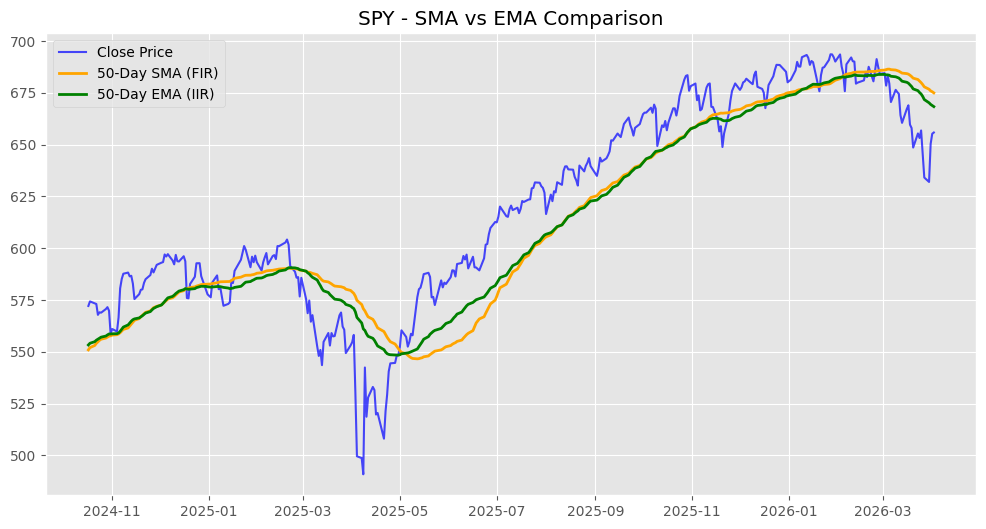

In [38]:

import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import pandas as pd
from scipy import signal, stats
import warnings
TICKER = 'SPY'
INTERVAL = '1d'
WINDOW = 50
df = yf.download(TICKER, start="1993-01-01", interval=INTERVAL, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

df['SMA'] = df['Close'].rolling(WINDOW).mean()
df['EMA'] = df['Close'].ewm(span=WINDOW, adjust=False).mean()
df_subset = df.iloc[-365:]
plt.figure(figsize=(12, 6))

plt.plot(df_subset.index, df_subset['Close'], label='Close Price', color='blue', alpha=0.7)
plt.plot(df_subset.index, df_subset['SMA'], label='50-Day SMA (FIR)', color='orange', lw=2)
plt.plot(df_subset.index, df_subset['EMA'], label='50-Day EMA (IIR)', color='green', lw=2)
plt.title(f"{TICKER} - SMA vs EMA Comparison")
plt.legend()
plt.show()

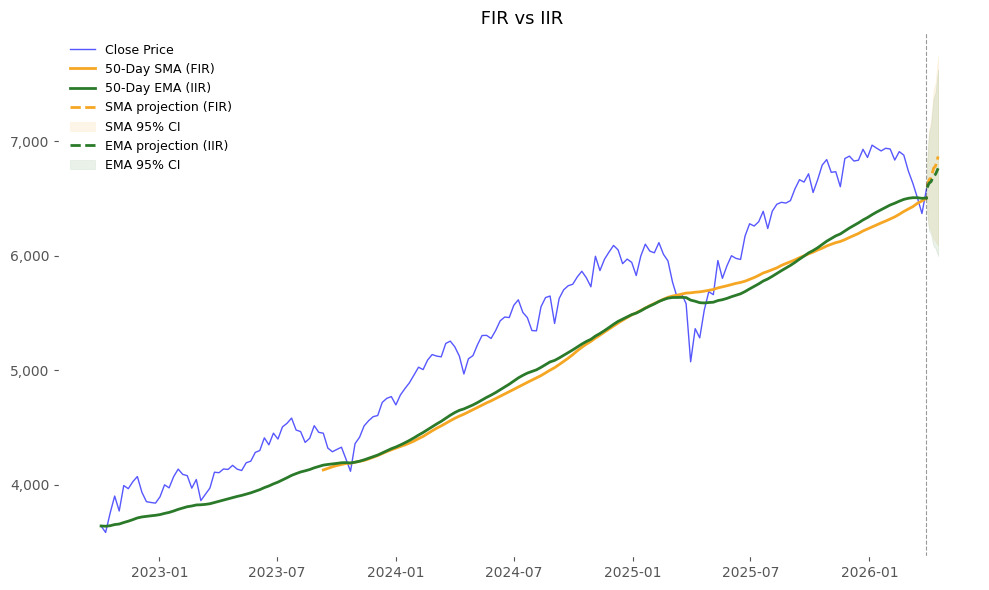

In [39]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

TICKER      = '^GSPC'
WINDOW      = 50
HORIZON     = 14
EWMA_LAMBDA = 0.94

df = yf.download(TICKER, start="2022-10-01", interval='1WK', progress=False)

if df.empty:
    print("Error: No data found.")
else:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    #qua lọc
    df['SMA'] = df['Close'].rolling(WINDOW).mean()          # FIR (equal weights)
    df['EMA'] = df['Close'].ewm(span=WINDOW, adjust=False).mean()  # IIR (decaying weights)

    log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna()
    sigma2 = np.zeros(len(log_ret))
    sigma2[0] = log_ret.iloc[0] ** 2
    for t in range(1, len(log_ret)):
        sigma2[t] = EWMA_LAMBDA * sigma2[t-1] + (1 - EWMA_LAMBDA) * log_ret.iloc[t-1]**2
    vol_now = np.sqrt(sigma2[-1])

    x_seg = np.arange(HORIZON)
    last_price = float(df['Close'].iloc[-1])

    slope_sma = stats.linregress(x_seg, df['SMA'].iloc[-HORIZON:].values).slope
    drift_sma = slope_sma / last_price   
    slope_ema = stats.linregress(x_seg, df['EMA'].iloc[-HORIZON:].values).slope
    drift_ema = slope_ema / last_price   

    steps = np.arange(1, HORIZON + 1)
    future_dates = pd.date_range(start=df.index[-1], periods=HORIZON + 1, freq='B')[1:]

    def gbm_path(drift):
        path  = last_price * np.exp((drift - 0.5 * vol_now**2) * steps)
        upper = path * np.exp( 1.96 * vol_now * np.sqrt(steps))
        lower = path * np.exp(-1.96 * vol_now * np.sqrt(steps))
        return path, upper, lower

    path_sma, upper_sma, lower_sma = gbm_path(drift_sma)  # FIR input
    path_ema, upper_ema, lower_ema = gbm_path(drift_ema)  # IIR input



   # Plot
    df_subset = df.iloc[-365:]
    fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
    ax.set_facecolor('white')

    ax.plot(df_subset.index, df_subset['Close'],
            color='#3a3aff', lw=1, alpha=0.85, label='Close Price')
    ax.plot(df_subset.index, df_subset['SMA'],
            color='#f5a623', lw=2, label=f'{WINDOW}-Day SMA (FIR)')
    ax.plot(df_subset.index, df_subset['EMA'],
            color='#2a7a2a', lw=2, label=f'{WINDOW}-Day EMA (IIR)')

    ax.plot(future_dates, path_sma,
            color='#f5a623', ls='--', lw=2, label='SMA projection (FIR)')
    ax.fill_between(future_dates, lower_sma, upper_sma,
                    color='#f5a623', alpha=0.10, label='SMA 95% CI')

    ax.plot(future_dates, path_ema,
            color='#2a7a2a', ls='--', lw=2, label='EMA projection (IIR)')
    ax.fill_between(future_dates, lower_ema, upper_ema,
                    color='#2a7a2a', alpha=0.10, label='EMA 95% CI')

    ax.axvline(df.index[-1], color='black', lw=0.8, ls='--', alpha=0.4)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    ax.set_title(" FIR vs IIR", fontsize=13)
    ax.legend(loc='upper left', frameon=False, fontsize=9)
    ax.grid(False)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

Fetching data for SPY...

── SMA 50 (Accumulate, no sell) ──
  Buys       : 78
  Units held : 78
  Avg cost   : $498.59
  Final val  : $51,154.74  (spent $38,889.93)
  Return     : +31.54%

── EMA 50 (Accumulate, no sell) ──
  Buys       : 91
  Units held : 91
  Avg cost   : $480.97
  Final val  : $59,680.53  (spent $43,768.11)
  Return     : +36.36%

── SMA 20x50 (Crossover) ──
  Trades     : 10
  Win rate   : 50.0%
  Avg return : +1.90% per trade
  Total      : +14.92%

── EMA 20x50 (Crossover) ──
  Trades     : 9
  Win rate   : 44.4%
  Avg return : +3.84% per trade
  Total      : +52.16%


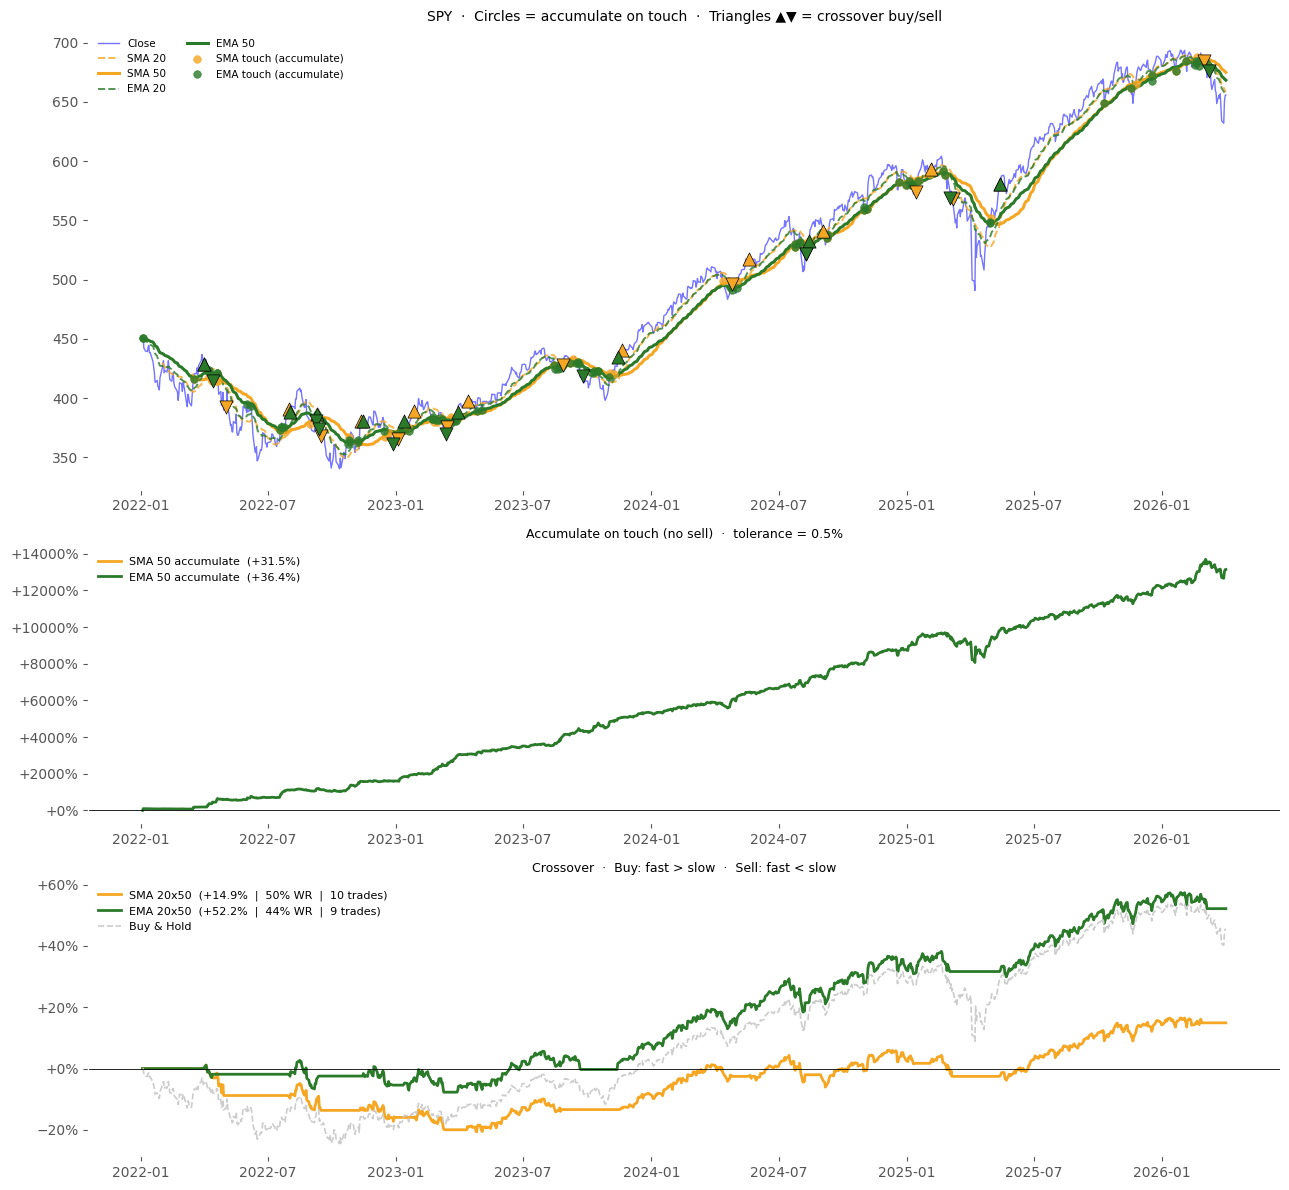

In [40]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

TICKER    = 'SPY'
FAST      = 20
SLOW      = 50
TOUCH_TOL = 0.005   # price within 0.5% of slow MA = "touching"

print(f"Fetching data for {TICKER}...")
df = yf.download(TICKER, start="2022-01-01", interval='1d', progress=False)

if df.empty:
    print("Error: No data found.")
else:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    close = df['Close']

    df['SMA_fast'] = close.rolling(FAST).mean()
    df['SMA_slow'] = close.rolling(SLOW).mean()
    df['EMA_fast'] = close.ewm(span=FAST, adjust=False).mean()
    df['EMA_slow'] = close.ewm(span=SLOW, adjust=False).mean()

    # ── Strategy 1: Accumulate on touch (no sell) ──────────────────────────────
    # Buy a fixed unit every time price touches the slow MA (within TOUCH_TOL)
    # Portfolio value = sum of all units × current price
    def backtest_accumulate(slow, label):
        units       = 0.0
        cash_spent  = 0.0
        equity      = []
        buy_dates   = []
        buy_prices  = []

        for i in range(len(df)):
            p = float(close.iloc[i])
            s = float(slow.iloc[i])

            if np.isnan(s):
                equity.append(np.nan)
                continue

            touching = (abs(p - s) / s) < TOUCH_TOL
            if touching:
                # Buy 1 unit at current price
                units      += 1.0
                cash_spent += p
                buy_dates.append(df.index[i])
                buy_prices.append(p)

            equity.append(units * p)   # mark-to-market value

        equity_s   = pd.Series(equity, index=df.index)
        avg_cost   = cash_spent / units if units > 0 else 0
        final_val  = float(close.iloc[-1]) * units
        total_ret  = (final_val / cash_spent - 1) * 100 if cash_spent > 0 else 0

        print(f"\n── {label} (Accumulate, no sell) ──")
        print(f"  Buys       : {len(buy_dates)}")
        print(f"  Units held : {units:.0f}")
        print(f"  Avg cost   : ${avg_cost:,.2f}")
        print(f"  Final val  : ${final_val:,.2f}  (spent ${cash_spent:,.2f})")
        print(f"  Return     : {total_ret:+.2f}%")

        return equity_s, buy_dates, buy_prices, total_ret

    # ── Strategy 2: Crossover buy/sell (no price filter) ───────────────────────
    # Buy  when fast crosses above slow (golden cross)
    # Sell when fast crosses below slow (death cross)
    def backtest_crossover(fast, slow, label):
        cross_up   = (fast > slow) & (fast.shift(1) <= slow.shift(1))
        cross_down = (fast < slow) & (fast.shift(1) >= slow.shift(1))

        position    = 0
        equity      = [1.0]
        entry_price = None
        trades      = []

        for i in range(1, len(df)):
            p = float(close.iloc[i])

            if position == 0 and cross_up.iloc[i]:
                position    = 1
                entry_price = p
                trades.append({'date': df.index[i], 'type': 'BUY', 'price': p})

            elif position == 1 and cross_down.iloc[i]:
                position = 0
                ret      = p / entry_price - 1
                trades.append({'date': df.index[i], 'type': 'SELL', 'price': p, 'return': ret})

            if position == 1:
                equity.append(equity[-1] * (p / float(close.iloc[i-1])))
            else:
                equity.append(equity[-1])

        trades_df = pd.DataFrame(trades)
        equity_s  = pd.Series(equity, index=df.index)
        sells     = trades_df[trades_df['type'] == 'SELL'] if not trades_df.empty else pd.DataFrame()
        n         = len(sells)
        wr        = (sells['return'] > 0).mean() * 100 if n > 0 else 0
        avg_r     = sells['return'].mean() * 100        if n > 0 else 0
        total_r   = (equity_s.iloc[-1] - 1) * 100

        print(f"\n── {label} (Crossover) ──")
        print(f"  Trades     : {n}")
        print(f"  Win rate   : {wr:.1f}%")
        print(f"  Avg return : {avg_r:+.2f}% per trade")
        print(f"  Total      : {total_r:+.2f}%")

        return equity_s, trades_df, total_r, wr, n

    eq_acc_sma, acc_dates_sma, acc_prices_sma, ret_acc_sma = backtest_accumulate(
        df['SMA_slow'], f"SMA {SLOW}")
    eq_acc_ema, acc_dates_ema, acc_prices_ema, ret_acc_ema = backtest_accumulate(
        df['EMA_slow'], f"EMA {SLOW}")

    eq_cross_sma, tr_sma, ret_sma, wr_sma, n_sma = backtest_crossover(
        df['SMA_fast'], df['SMA_slow'], f"SMA {FAST}x{SLOW}")
    eq_cross_ema, tr_ema, ret_ema, wr_ema, n_ema = backtest_crossover(
        df['EMA_fast'], df['EMA_slow'], f"EMA {FAST}x{SLOW}")

    bh = close / float(close.iloc[0])

    # ── Plot ───────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(13, 12), facecolor='white',
                             gridspec_kw={'height_ratios': [3, 1.8, 1.8]})
    fig.subplots_adjust(hspace=0.38)

    # Panel 1: Price + MAs + all trade markers
    ax1 = axes[0]
    ax1.set_facecolor('white')
    ax1.plot(close.index, close,
             color='#3a3aff', lw=1, alpha=0.7, label='Close')
    ax1.plot(df.index, df['SMA_fast'],
             color='#f5a623', lw=1.4, ls='--', alpha=0.8, label=f'SMA {FAST}')
    ax1.plot(df.index, df['SMA_slow'],
             color='#f5a623', lw=2.2, label=f'SMA {SLOW}')
    ax1.plot(df.index, df['EMA_fast'],
             color='#2a7a2a', lw=1.4, ls='--', alpha=0.8, label=f'EMA {FAST}')
    ax1.plot(df.index, df['EMA_slow'],
             color='#2a7a2a', lw=2.2, label=f'EMA {SLOW}')

    # Accumulate markers (circles)
    ax1.scatter(acc_dates_sma, acc_prices_sma,
                marker='o', color='#f5a623', s=30, zorder=5,
                label='SMA touch (accumulate)', alpha=0.8)
    ax1.scatter(acc_dates_ema, acc_prices_ema,
                marker='o', color='#2a7a2a', s=30, zorder=5,
                label='EMA touch (accumulate)', alpha=0.8)

    # Crossover markers (triangles)
    for tr, color in [(tr_sma, '#f5a623'), (tr_ema, '#2a7a2a')]:
        if not tr.empty:
            buys  = tr[tr['type'] == 'BUY']
            sells = tr[tr['type'] == 'SELL']
            ax1.scatter(buys['date'],  buys['price'],
                        marker='^', color=color, s=90, zorder=6, edgecolors='black', lw=0.5)
            ax1.scatter(sells['date'], sells['price'],
                        marker='v', color=color, s=90, zorder=6, edgecolors='black', lw=0.5)

    ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    ax1.set_title(f"{TICKER}  ·  Circles = accumulate on touch  ·  "
                  f"Triangles ▲▼ = crossover buy/sell",
                  fontsize=10)
    ax1.legend(loc='upper left', frameon=False, fontsize=7.5, ncol=2)
    ax1.spines[['top', 'right']].set_visible(False)

    # Panel 2: Accumulate equity (normalised to % gain on cash spent)
    ax2 = axes[1]
    ax2.set_facecolor('white')
    # Normalise accumulate equity to first non-nan value for comparison
    acc_sma_norm = eq_acc_sma / eq_acc_sma.dropna().iloc[0] - 1
    acc_ema_norm = eq_acc_ema / eq_acc_ema.dropna().iloc[0] - 1
    ax2.plot(acc_sma_norm.index, acc_sma_norm * 100,
             color='#f5a623', lw=2, label=f'SMA {SLOW} accumulate  ({ret_acc_sma:+.1f}%)')
    ax2.plot(acc_ema_norm.index, acc_ema_norm * 100,
             color='#2a7a2a', lw=2, label=f'EMA {SLOW} accumulate  ({ret_acc_ema:+.1f}%)')
    ax2.axhline(0, color='black', lw=0.6)
    ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:+.0f}%"))
    ax2.set_title(f"Accumulate on touch (no sell)  ·  "
                  f"tolerance = {TOUCH_TOL*100:.1f}%", fontsize=9)
    ax2.legend(frameon=False, fontsize=8)
    ax2.spines[['top', 'right']].set_visible(False)

    # Panel 3: Crossover equity vs buy-and-hold
    ax3 = axes[2]
    ax3.set_facecolor('white')
    ax3.plot(eq_cross_sma.index, (eq_cross_sma - 1) * 100,
             color='#f5a623', lw=2,
             label=f'SMA {FAST}x{SLOW}  ({ret_sma:+.1f}%  |  {wr_sma:.0f}% WR  |  {n_sma} trades)')
    ax3.plot(eq_cross_ema.index, (eq_cross_ema - 1) * 100,
             color='#2a7a2a', lw=2,
             label=f'EMA {FAST}x{SLOW}  ({ret_ema:+.1f}%  |  {wr_ema:.0f}% WR  |  {n_ema} trades)')
    ax3.plot(bh.index, (bh - 1) * 100,
             color='#cccccc', lw=1.2, ls='--', label='Buy & Hold')
    ax3.axhline(0, color='black', lw=0.6)
    ax3.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:+.0f}%"))
    ax3.set_title(f"Crossover  ·  Buy: fast > slow  ·  Sell: fast < slow", fontsize=9)
    ax3.legend(frameon=False, fontsize=8)
    ax3.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()